In [2]:
import pandas as pd
import seaborn as sns
%matplotlib inline

# Dimension reduction and clustering libraries
import math

%load_ext autoreload
%autoreload 2
import sys

sys.path.append(base_path)
from pathlib import Path
import jupyter_notebooks.plotting_func as pf

In [ ]:
base_path = "/home/kunzj"
job_dir = "/home/kunzj/internship_uva_compchem/Data/iteration_0/binder_md_sim/jobs"
sub_dir = "7.analysis"
file_numbers = ["1"] * 102

In [ ]:
file_name = "rmsd_CA_pro_to_whole_pep.xvg"
av_means_rmsd, av_std_rmsd = pf.rmsd_mean_std_calc(
    job_dir=job_dir,
    sub_dir=sub_dir,
    file_name=file_name,
    file_numbers=file_numbers,
)

In [ ]:
file_name = "sasa_prot.xvg"
av_means_sasa, av_std_sasa = pf.sasa_mean_std_calc(
    job_dir=job_dir,
    sub_dir=sub_dir,
    file_name=file_name,
    file_numbers=file_numbers,
    base_path=base_path,
    range_frames=slice(5, 50),
)

In [ ]:
df_all_switch_hbond = pf.hbond_ana_switch(
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/md_sim_analysis/hbond/peptide_acceptor/",
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/md_sim_analysis/hbond/peptide_donor/",
    set(range(240, 2040)).intersection(range(0, 2040, 40)),
)
av_means_hbond_switch_func = {}
av_std_hbond_switch_func = {}
for idx in df_all_switch_hbond.keys():
    av_means_hbond_switch_func[idx] = df_all_switch_hbond[idx][4][0]
    av_std_hbond_switch_func[idx] = df_all_switch_hbond[idx][4][1]

av_means_hbond_switch_func = {
    k: av_means_hbond_switch_func[k] for k in sorted(av_means_hbond_switch_func.keys())
}
av_std_hbond_switch_func = {
    k: av_std_hbond_switch_func[k] for k in sorted(av_std_hbond_switch_func.keys())
}

In [ ]:
mmpbsa_energies = pf.peptides_mmpbsa_energys(
    folder_name=Path("/home/kunzj/internship_uva_compchem/Data/iteration_0/md_sim_analysis/mmpbsa/jobs/"),
    handpick_frames=set(range(240, 2040)).intersection(range(0, 2040, 40)),
)

folder_ranked_peptides = Path(
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/bindcraft/Accepted/Ranked"
)


sequences = pf.sequence_retrieval(folder_ranked_peptides)


In [ ]:
df_all_switch_sbridge = pf.sbridge_ana_switch(
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/md_sim_analysis/sbridge/peptide_negative",
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/md_sim_analysis/sbridge/peptide_positive",
    set(range(240, 2040)).intersection(range(0, 2040, 40)),
)
av_means_sbridge_switch_func = {}
av_std_sbridge_switch_func = {}
for idx in df_all_switch_sbridge.keys():
    av_means_sbridge_switch_func[idx] = df_all_switch_sbridge[idx][4][0]
    av_std_sbridge_switch_func[idx] = df_all_switch_sbridge[idx][4][1]

av_means_sbridge_switch_func = {
    k: av_means_sbridge_switch_func[k]
    for k in sorted(av_means_sbridge_switch_func.keys())
}
av_std_sbridge_switch_func = {
    k: av_std_sbridge_switch_func[k] for k in sorted(av_std_sbridge_switch_func.keys())
}
for k in av_means_sbridge_switch_func.keys():
    if math.isnan(av_means_sbridge_switch_func[k]):
        av_means_sbridge_switch_func[k] = 0.0
        av_std_sbridge_switch_func[k] = 0.0

In [14]:
df = pd.DataFrame(
    index=range(1, 103), columns=("sbridge", "hbond", "energies", "bsa", "rmsd")
)
for i in range(1, 103):
    df.loc[i, "sbridge"] = av_means_sbridge_switch_func[i]
    df.loc[i, "hbond"] = av_means_hbond_switch_func[i]
    df.loc[i, "energies"] = mmpbsa_energies[i]
    df.loc[i, "bsa"] = av_means_sasa[i]
    df.loc[i, "rmsd"] = av_std_rmsd[i]
df.fillna(0, inplace=True)  # fill binders with no sbdridge with zeros


In [15]:
for metric in [av_means_sbridge_switch_func, av_means_hbond_switch_func, mmpbsa_energies, av_means_sasa, av_std_rmsd]:
    if len(metric) != 102:
        print("Metric length issue:", metric)

In [16]:
df

,sbridge,hbond,energies,bsa,rmsd
1,0.866667,3.41876,-59.887556,-1.207561,0.032356
2,0.933333,5.417951,-68.760222,-1.087171,0.044972
3,0.999927,2.716315,-60.869111,-1.966902,0.03478
4,1.037036,3.173115,-62.515333,-1.434341,0.030395
5,0.0,4.706482,-76.602667,-0.614317,0.033116
...,...,...,...,...,...
98,1.0,3.446151,-67.412222,0.225171,0.0473
99,0.0,2.110791,-69.751556,-1.278488,0.079703
100,1.416662,2.650419,-63.164222,-1.026195,0.056033
101,0.999967,3.792086,-73.852889,-0.979585,0.055299


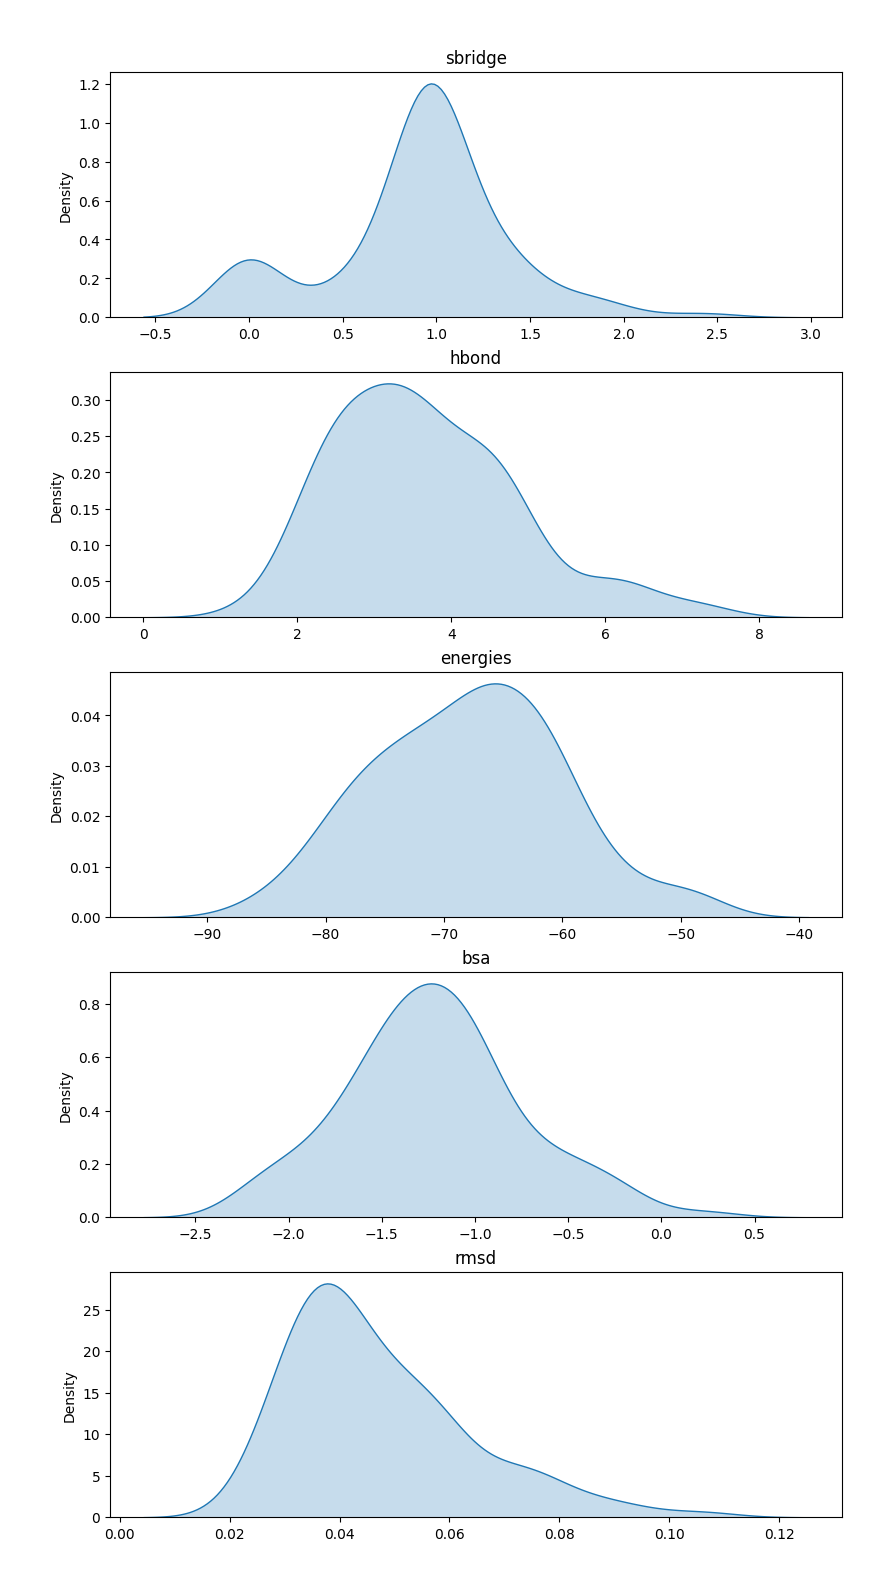

In [19]:
import matplotlib.pyplot as plt

cols = df.columns.tolist()
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 3 * len(cols)), constrained_layout=True)

if len(cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cols):
    sns.kdeplot(data=df[col].dropna().astype(float), fill=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.show()

In [ ]:
df_raw = df.reset_index()
df_raw.rename(columns={"index": "Binder_ID"}, inplace=True)
df_raw.to_csv(
    "/home/kunzj/internship_uva_compchem/Data/iteration_0/score/md_data_all_binders_raw.csv"
)
